📊 30 MIPYMES, 12 productos

📋 Top 5 más difíciles:
• Sal: 26.7%
• Huevos: 33.3%
• Papel Higienico: 33.3%
• Detergente: 43.3%
• Pechuga de pollo: 50.0%


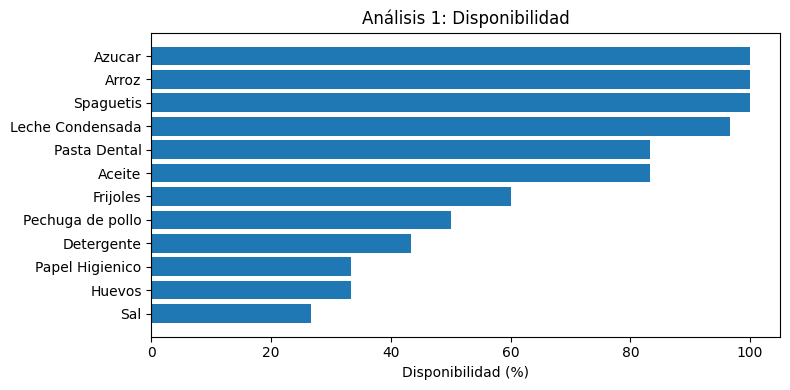

In [1]:

import sys
sys.path.append('../Src')

# 1. Importar funciones
import A1 as fa

# 2. Cargar y analizar
datos = fa.cargar_datos('../Data/procesados/productos_planos.json')
resultados, total = fa.calcular_disponibilidad(datos)

# 3. Mostrar
print(f"📊 {total} MIPYMES, {len(resultados)} productos")
print("\n📋 Top 5 más difíciles:")
for prod, pct, cant in resultados[:5]:
    print(f"• {prod}: {pct:.1f}%")

# 4. Gráfico
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))
plt.barh([r[0] for r in resultados], [r[1] for r in resultados])
plt.xlabel('Disponibilidad (%)')
plt.title('Análisis 1: Disponibilidad')
plt.tight_layout()
plt.show()

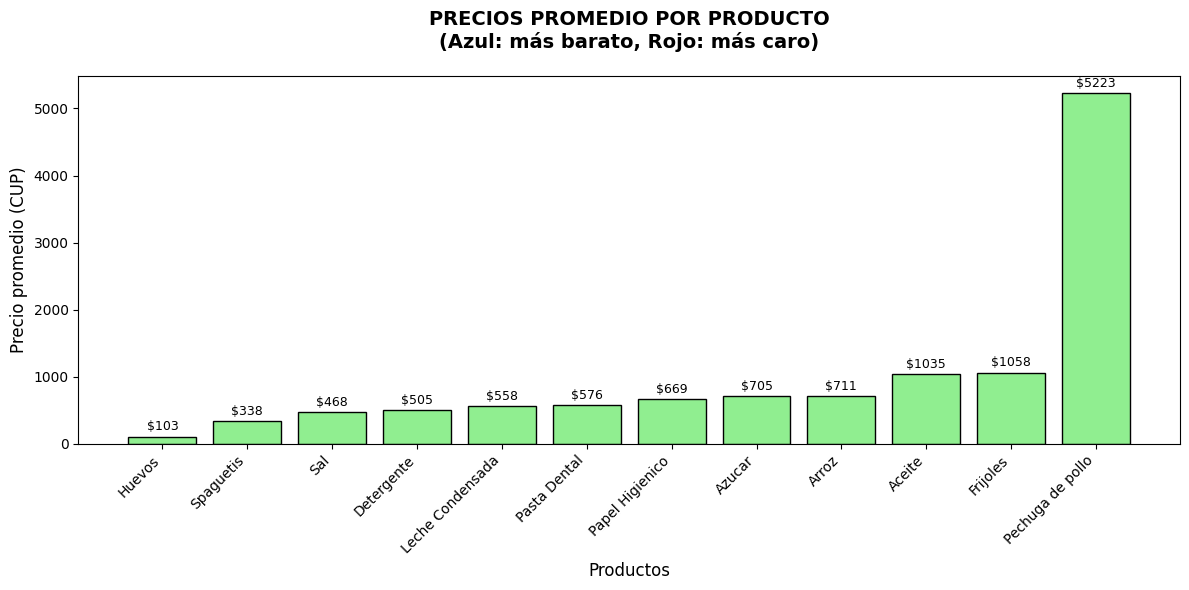

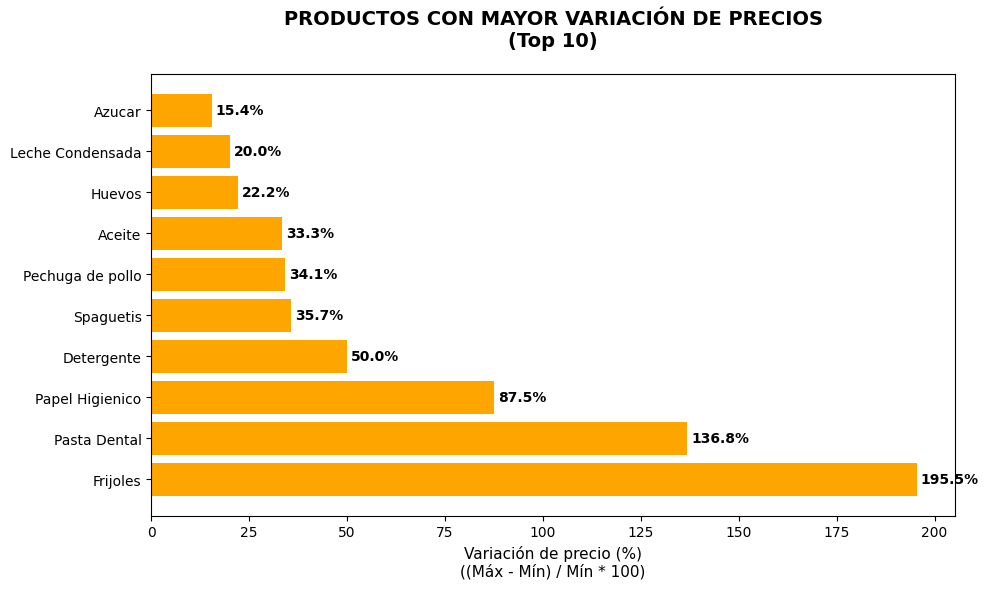

In [2]:
# notebooks/analisis2.ipynb

import sys
sys.path.append('../Src')

# Importar funciones de precios
import A2 as pr
import A1 as an

datos = an.cargar_datos('../Data/procesados/productos_planos.json')
precios = pr.calcular_precios(datos)


import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Extraer datos
productos = [p['producto'] for p in precios]
promedios = [p['promedio'] for p in precios]

# Crear gráfico de barras
bars = plt.bar(productos, promedios, color='lightgreen', edgecolor='black')

# Personalizar
plt.xlabel('Productos', fontsize=12)
plt.ylabel('Precio promedio (CUP)', fontsize=12)
plt.title('PRECIOS PROMEDIO POR PRODUCTO\n(Azul: más barato, Rojo: más caro)',
          fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')

# Agregar valores en las barras
for bar, promedio in zip(bars, promedios):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 50,
             f'${promedio:.0f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))

# Calcular variaciones
variaciones = pr.calcular_variacion_precios(precios)

# Tomar los 10 con mayor variación
top_variaciones = variaciones[:10]

productos_var = [v['producto'] for v in top_variaciones]
valores_var = [v['variacion'] for v in top_variaciones]

# Gráfico de barras horizontales
plt.barh(productos_var, valores_var, color='orange')

plt.xlabel('Variación de precio (%)\n((Máx - Mín) / Mín * 100)', fontsize=11)
plt.title('PRODUCTOS CON MAYOR VARIACIÓN DE PRECIOS\n(Top 10)',
          fontsize=14, fontweight='bold', pad=20)

# Agregar valores
for i, (prod, var) in enumerate(zip(productos_var, valores_var)):
    plt.text(var + 1, i, f'{var:.1f}%', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Calcular estadísticas generales
todos_precios = []
for registro in datos:
    todos_precios.append(registro['precio_cup'])

precio_promedio_general = sum(todos_precios) / len(todos_precios)



📊 Fuente: Oficina Nacional de Estadística e Información de Cuba (ONEI)
📅 Fecha: Septiembre 2025
📈 Actividades económicas: 18


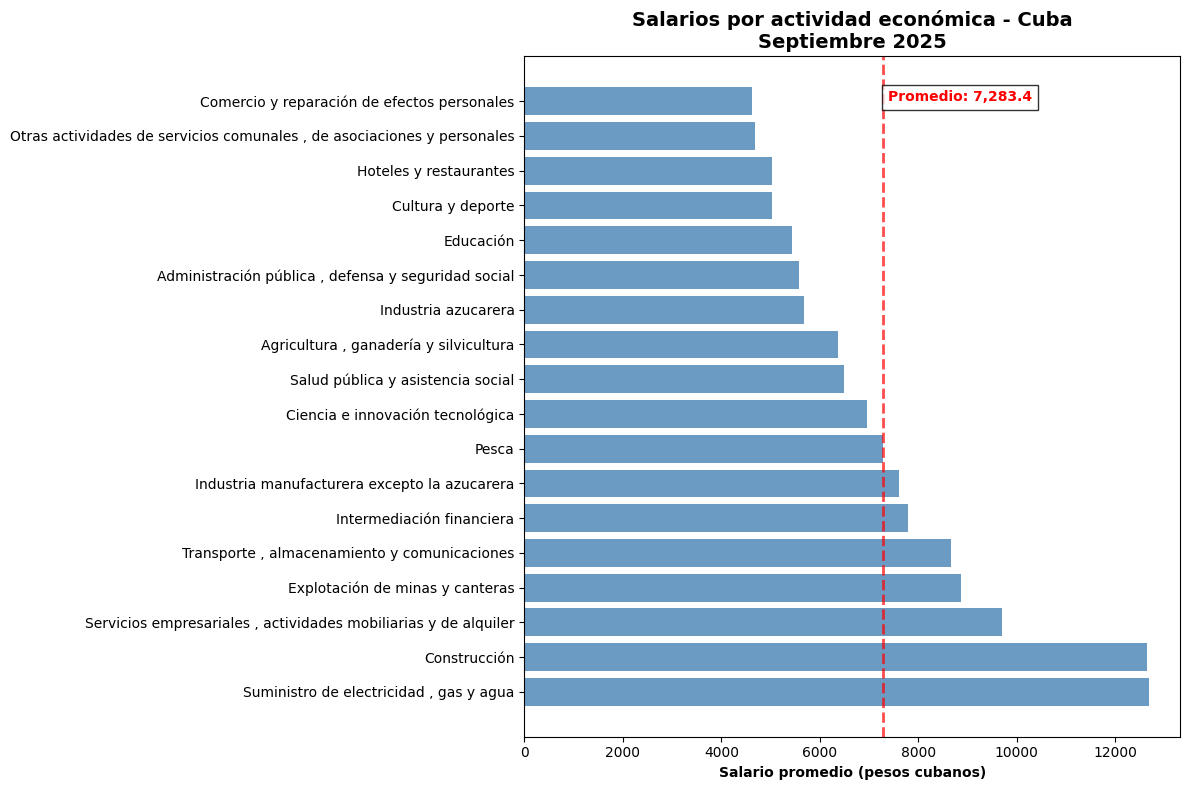

In [3]:
# notebook.ipynb

# Celda 1: Cargar directamente el JSON procesado
import json
import os

# Ruta al archivo procesado (ajusta según tu estructura)
with open('../Data/Crudos/salarios_cuba/salarios_procesados.json', 'r', encoding='utf-8') as f:
    datos = json.load(f)

print(f"📊 Fuente: {datos['fuente']}")
print(f"📅 Fecha: {datos['fecha_datos']}")
print(f"📈 Actividades económicas: {len(datos['salarios_ordenados'])}")

# Celda 2: Gráfico simple
import matplotlib.pyplot as plt

actividades = list(datos['salarios_ordenados'].keys())
salarios = list(datos['salarios_ordenados'].values())

plt.figure(figsize=(12, 8))
bars = plt.barh(actividades, salarios, color='steelblue', alpha=0.8)

# Personalizar
plt.xlabel('Salario promedio (pesos cubanos)', fontweight='bold')
plt.title(f'Salarios por actividad económica - Cuba\n{datos["fecha_datos"]}', fontsize=14, fontweight='bold')

# Línea de promedio
promedio = sum(salarios) / len(salarios)
plt.axvline(x=promedio, color='red', linestyle='--', linewidth=2, alpha=0.7)
plt.text(promedio + 100, len(actividades)-1, f'Promedio: {promedio:,.1f}',
         color='red', fontweight='bold', bbox=dict(facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

Productos cargados: 243 registros


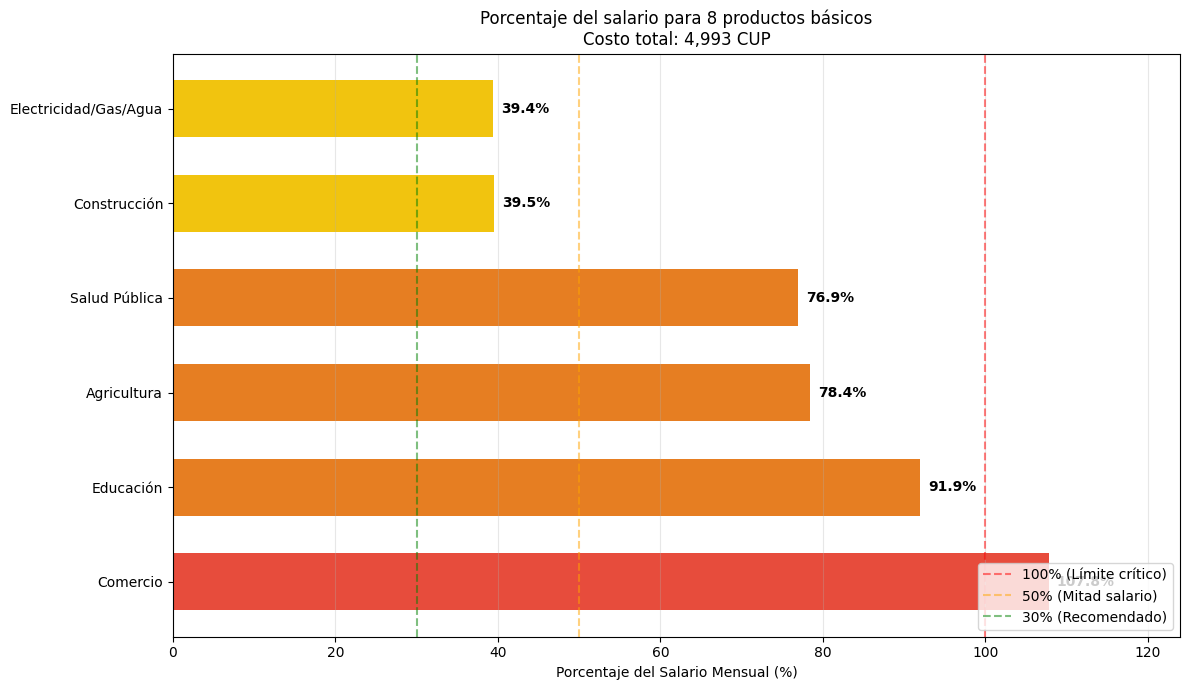

In [7]:

import json
import sys
from matplotlib import pyplot as plt

sys.path.append('../Src')
# Configuración simple
plt.rcParams['figure.figsize'] = (12, 7)

# Celda 2: Cargar datos
# Cargar productos
with open('../Data/Procesados/productos_planos.json', 'r', encoding='utf-8') as f:
    productos = json.load(f)

print(f"Productos cargados: {len(productos)} registros")

# Celda 3: Importar y ejecutar análisis
from A4 import analizar_asequibilidad

# Ejecutar análisis
resultados, costo_canasta, resumen = analizar_asequibilidad(
    ruta_salarios='../Data/Crudos/salarios_cuba/salarios.json',
    productos=productos
)

# Celda 4: Preparar datos para el gráfico
sectores = list(resultados.keys())
porcentajes = [resultados[s]['porcentaje'] for s in sectores]

# Ordenar de mayor a menor
datos_ordenados = sorted(zip(sectores, porcentajes), key=lambda x: x[1], reverse=True)
sectores_ordenados = [d[0] for d in datos_ordenados]
porcentajes_ordenados = [d[1] for d in datos_ordenados]

# Simplificar nombres
nombres_cortos = []
for sector in sectores_ordenados:
    if sector == "Suministro de electricidad , gas y agua":
        nombres_cortos.append("Electricidad/Gas/Agua")
    elif sector == "Salud pública y asistencia social":
        nombres_cortos.append("Salud Pública")
    elif sector == "Agricultura , ganadería y silvicultura":
        nombres_cortos.append("Agricultura")
    elif sector == "Comercio y reparación de efectos personales":
        nombres_cortos.append("Comercio")
    else:
        nombres_cortos.append(sector)

# Celda 5: Crear UN SOLO GRÁFICO
fig, ax = plt.subplots()

# Colores según porcentaje
colores = []
for p in porcentajes_ordenados:
    if p > 100:
        colores.append('#e74c3c')  # Rojo
    elif p > 50:
        colores.append('#e67e22')  # Naranja
    elif p > 30:
        colores.append('#f1c40f')  # Amarillo
    else:
        colores.append('#2ecc71')  # Verde

# Barras horizontales
bars = ax.barh(nombres_cortos, porcentajes_ordenados, color=colores, height=0.6)

# Líneas de referencia
ax.axvline(x=100, color='red', linestyle='--', alpha=0.5, label='100% (Límite crítico)')
ax.axvline(x=50, color='orange', linestyle='--', alpha=0.5, label='50% (Mitad salario)')
ax.axvline(x=30, color='green', linestyle='--', alpha=0.5, label='30% (Recomendado)')

# Añadir valores a las barras
for bar, valor in zip(bars, porcentajes_ordenados):
    ax.text(bar.get_width() + 1,
            bar.get_y() + bar.get_height()/2,
            f'{valor:.1f}%',
            va='center',
            fontsize=10,
            fontweight='bold')

# Configurar gráfico
ax.set_xlabel('Porcentaje del Salario Mensual (%)')
ax.set_title(f'Porcentaje del salario para 8 productos básicos\nCosto total: {costo_canasta:,.0f} CUP')

# Leyenda
ax.legend(loc='lower right')

# Cuadrícula y límites
ax.grid(axis='x', alpha=0.3)
ax.set_xlim(0, max(porcentajes_ordenados) * 1.15)

# Mostrar gráfico
plt.tight_layout()
plt.show()


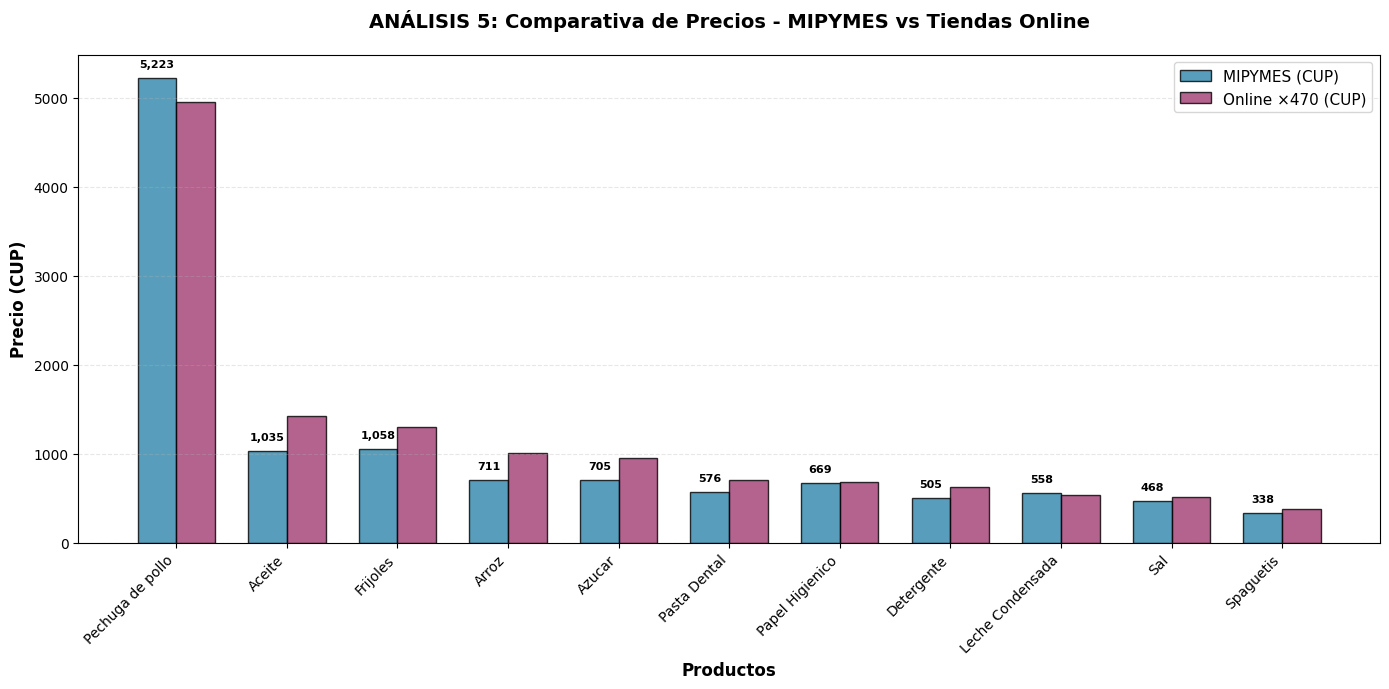

In [5]:

import sys
sys.path.append('../Src')
import matplotlib.pyplot as plt
import numpy as np
import A5 as a5


comparativa = a5.generar_comparativa(
    ruta_mipymes='../Data/Procesados/productos_planos.json',
    ruta_online='../Data/Procesados/online_planos.json',
    tasa_cambio=470
)

# Calcular estadísticas
diferencias = [p['diferencia'] for p in comparativa]
ratios = [p['ratio'] for p in comparativa]

# Preparar datos para gráfico
productos = [p['nombre'] for p in comparativa]
mipyme = [p['mipyme_cup'] for p in comparativa]
online = [p['online_cup'] for p in comparativa]

# Ordenar por precio online para mejor visualización
datos_ordenados = sorted(zip(productos, mipyme, online),
                         key=lambda x: x[2], reverse=True)
productos_ord, mipyme_ord, online_ord = zip(*datos_ordenados)

# Crear gráfico
x = np.arange(len(productos_ord))
ancho = 0.35

fig, ax = plt.subplots(figsize=(14, 7))

# Barras
barras_m = ax.bar(x - ancho/2, mipyme_ord, ancho,
                  label='MIPYMES (CUP)', color='#2E86AB', alpha=0.8, edgecolor='black')
barras_o = ax.bar(x + ancho/2, online_ord, ancho,
                  label='Online ×470 (CUP)', color='#A23B72', alpha=0.8, edgecolor='black')

# Personalización
ax.set_xlabel('Productos', fontsize=12, fontweight='bold')
ax.set_ylabel('Precio (CUP)', fontsize=12, fontweight='bold')
ax.set_title('ANÁLISIS 5: Comparativa de Precios - MIPYMES vs Tiendas Online',
             fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(productos_ord, rotation=45, ha='right', fontsize=10)
ax.legend(fontsize=11, loc='upper right')
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Añadir etiquetas a barras
for bar in barras_m:
    height = bar.get_height()
    if height < 50000:  # Limitar para mejor visualización
        ax.text(bar.get_x() + bar.get_width()/2, height + 100,
                f'{height:,.0f}', ha='center', va='bottom',
                fontsize=8, fontweight='bold')

# Destacar productos con mayor ratio
for i, prod in enumerate(comparativa):
    if prod['ratio'] > 10:  # Destacar productos >10x más caros online
        # Encontrar índice en lista ordenada
        idx = productos_ord.index(prod['nombre'])
        ax.text(idx, prod['online_cup'] * 0.5, f"{prod['ratio']:.1f}x",
                ha='center', va='center', fontsize=9, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='red', alpha=0.2))

plt.tight_layout()
plt.show()

# Encontrar producto con mayor y menor diferencia
max_diff = max(comparativa, key=lambda x: x['diferencia'])
min_diff = min(comparativa, key=lambda x: x['diferencia'])

# Contar productos por categoría de ratio
cat_1_5 = sum(1 for r in ratios if r <= 5)
cat_5_10 = sum(1 for r in ratios if 5 < r <= 10)
cat_10_plus = sum(1 for r in ratios if r > 10)